# Customer Churn Prediction using Feed-Forward Neural Networks

## 1. Introduction

This project aims to predict customer churn using a feed-forward neural network while analyzing training behavior, activation functions, learning rates, and model generalization performance.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [2]:
df = pd.read_csv("/content/customer_churn_nn.csv")

df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (2000, 17)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   object 
 1   region                        2000 non-null   object 
 2   plan_type                     2000 non-null   object 
 3   contract_type                 2000 non-null   object 
 4   payment_method                2000 non-null   object 
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_days_ago       2000 non-null   int64  
 13  dis

In [5]:
df.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


In [6]:
df.isnull().sum()

,0
customer_id,0
region,0
plan_type,0
contract_type,0
payment_method,0
tenure_months,0
monthly_charges_inr,0
avg_login_days_per_month,0
support_tickets_last_90_days,0
payment_delay_days,0


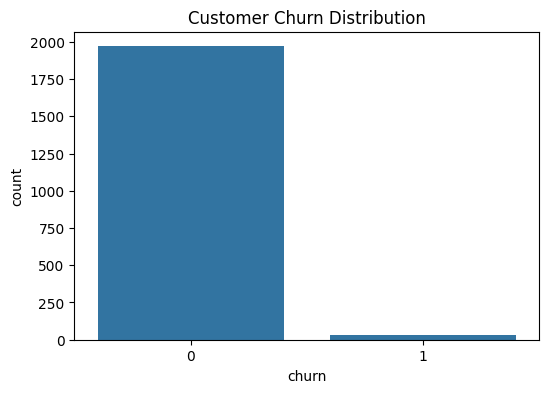

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(x='churn', data=df)

plt.title("Customer Churn Distribution")

plt.show()

In [8]:
print("Dataset Shape:", df.shape)

Dataset Shape: (2000, 17)


## 3. Dataset Understanding and Exploration

### Observations

- The dataset contains both categorical and numerical variables.
- The target variable `churn` represents a binary classification problem.
- Numerical features exist on different scales, making feature scaling important before neural network training.
- Customer behavior features such as payment delays, support tickets, and satisfaction scores may influence churn probability.
- The dataset appears suitable for supervised learning using a feed-forward neural network.

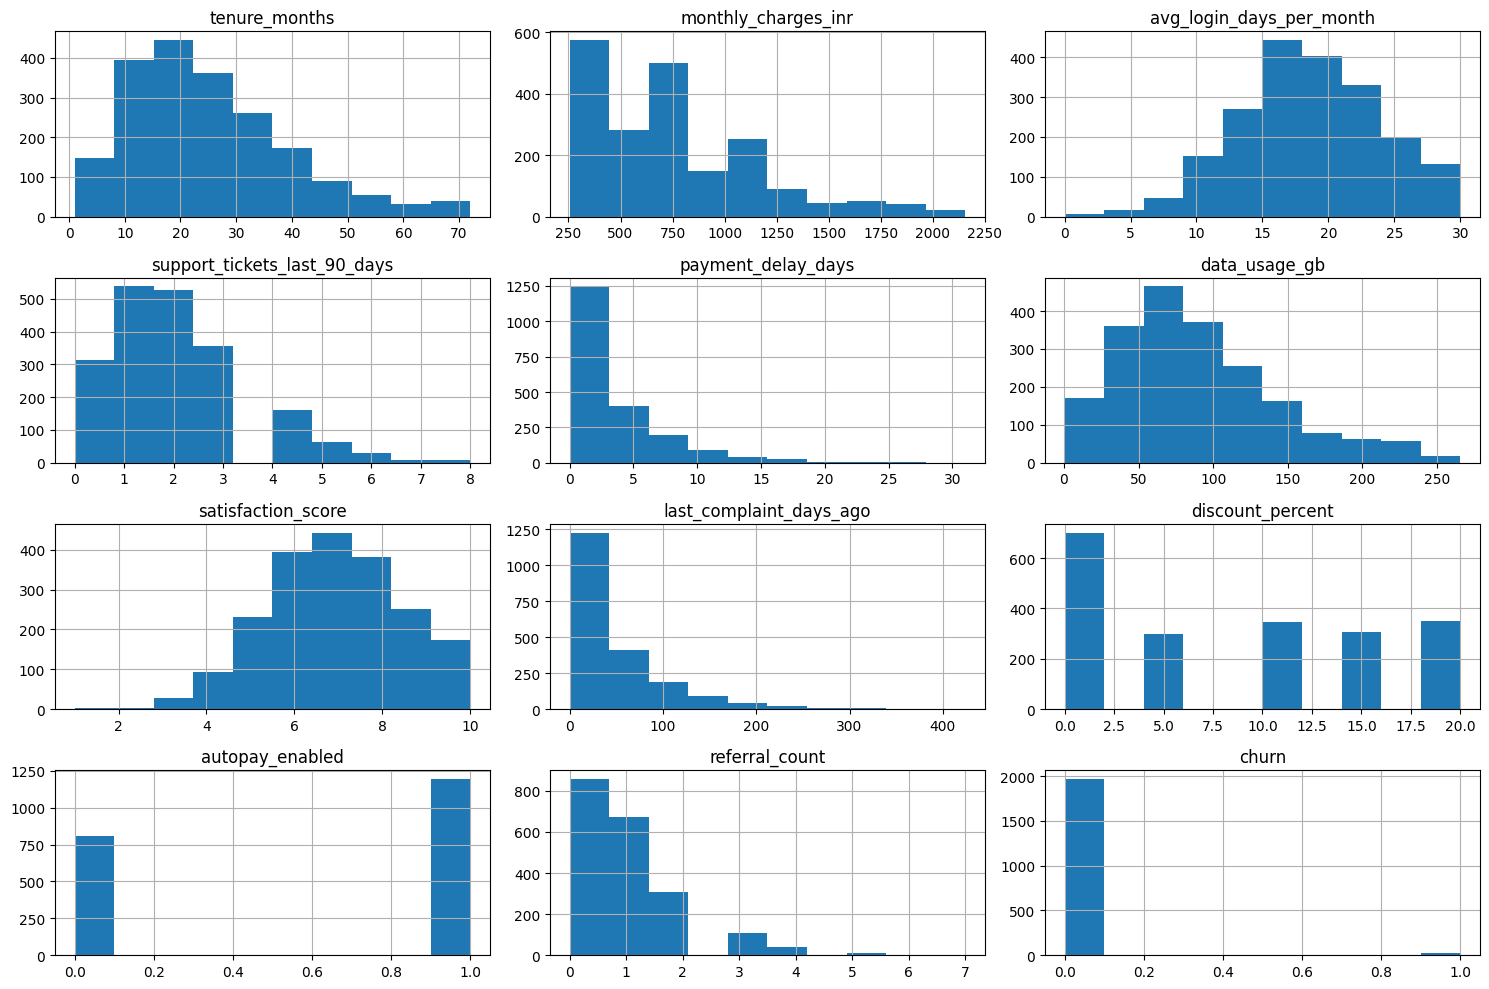

In [9]:
df.hist(figsize=(15,10))

plt.tight_layout()

plt.show()

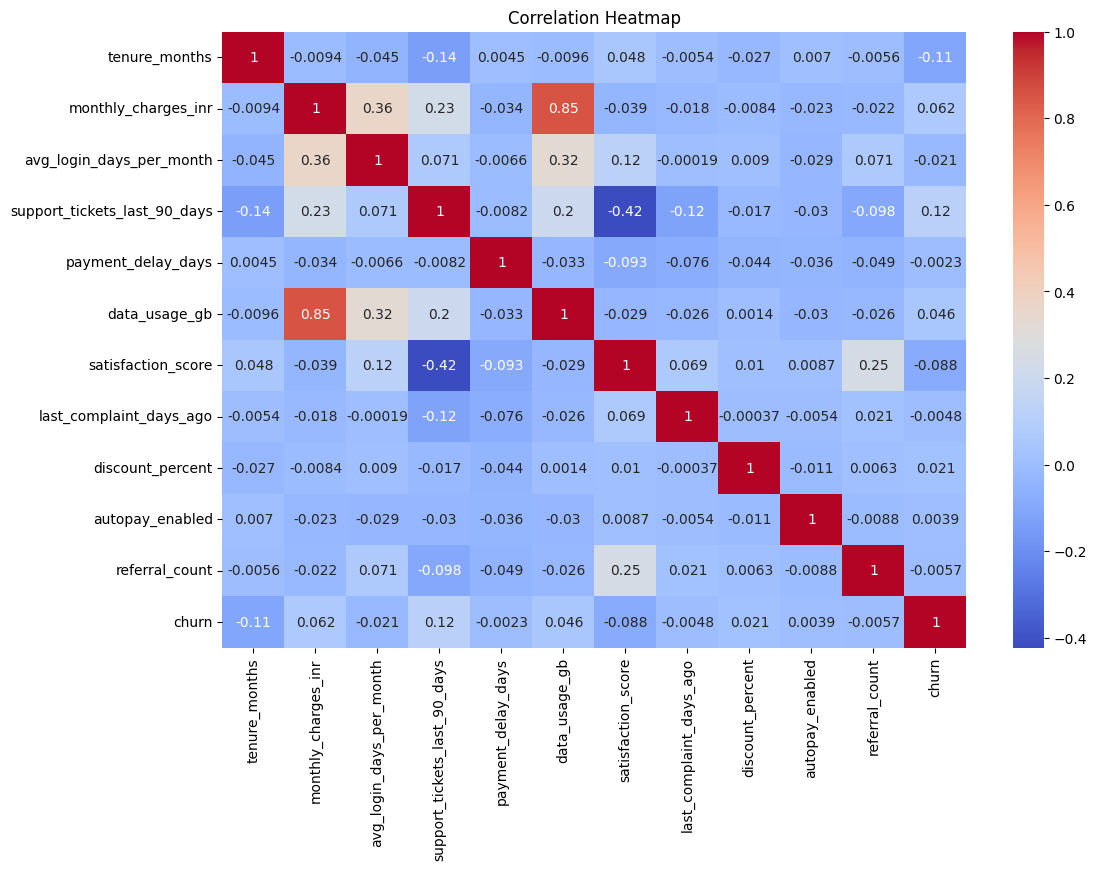

In [10]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# 4. Data Preprocessing

In [11]:
df.drop("customer_id", axis=1, inplace=True)

In [17]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,...,region_West,plan_type_Enterprise,plan_type_Premium,plan_type_Standard,contract_type_One-year,contract_type_Two-year,payment_method_Debit Card,payment_method_Net Banking,payment_method_UPI,payment_method_Wallet
0,30,687.40,13,0,0,87.97,8.0,67,0,0,...,False,False,False,True,False,False,True,False,False,False
1,15,1029.74,22,3,1,82.17,5.7,69,0,0,...,True,False,True,False,False,False,False,False,False,True
2,72,732.07,13,0,11,89.39,6.4,63,10,0,...,False,False,False,True,False,False,False,False,False,False
3,22,959.51,19,2,3,139.73,7.2,130,5,0,...,True,False,True,False,False,False,False,False,False,False
4,11,890.20,18,2,6,156.43,5.8,0,5,1,...,False,False,True,False,False,False,False,True,False,False


In [18]:
X = df.drop("churn", axis=1)

y = df["churn"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

### Preprocessing Explanation

Categorical variables were converted into numerical form using one-hot encoding. Feature scaling was performed using StandardScaler because neural networks are sensitive to feature magnitudes and require normalized input for stable gradient updates during backpropagation.

# 5. Neural Network Model Building

In [21]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,713 (14.50 KB)

 Trainable params: 3,713 (14.50 KB)

 Non-trainable params: 0 (0.00 B)

# 6. Model Training

In [24]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9008 - loss: 0.3458 - val_accuracy: 0.9937 - val_loss: 0.1137
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9820 - loss: 0.1127 - val_accuracy: 0.9937 - val_loss: 0.0499
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9820 - loss: 0.0915 - val_accuracy: 0.9937 - val_loss: 0.0408
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9820 - loss: 0.0854 - val_accuracy: 0.9937 - val_loss: 0.0390
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9820 - loss: 0.0775 - val_accuracy: 0.9937 - val_loss: 0.0371
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9820 - loss: 0.0730 - val_accuracy: 0.9937 - val_loss: 0.0363
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0737 - val_accuracy: 0.9937 - val_loss: 0.0357
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0707 - val_accuracy: 0.9937 - val_loss

# 7. Model Evaluation

In [25]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9850 - loss: 0.0777
Test Loss: 0.07773749530315399
Test Accuracy: 0.9850000143051147


In [26]:
y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       394
           1       0.00      0.00      0.00         6

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.98       400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


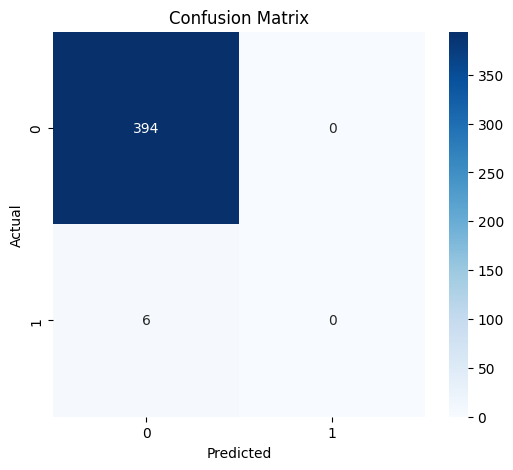

In [35]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig("confusion_matrix.png")

plt.show()

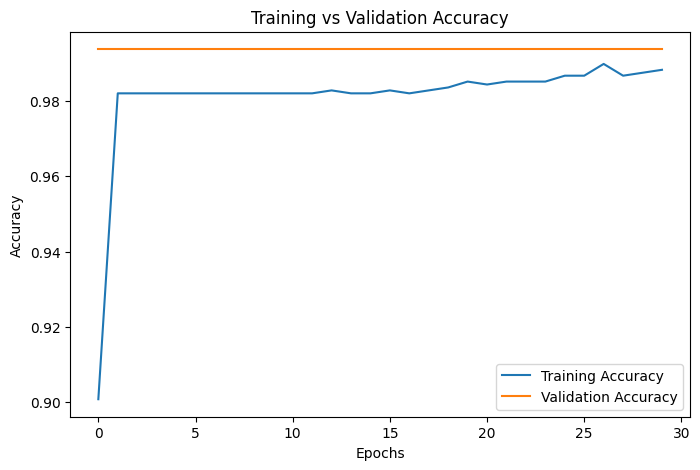

In [37]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend()

plt.savefig("accuracy_curve.png")

plt.show()

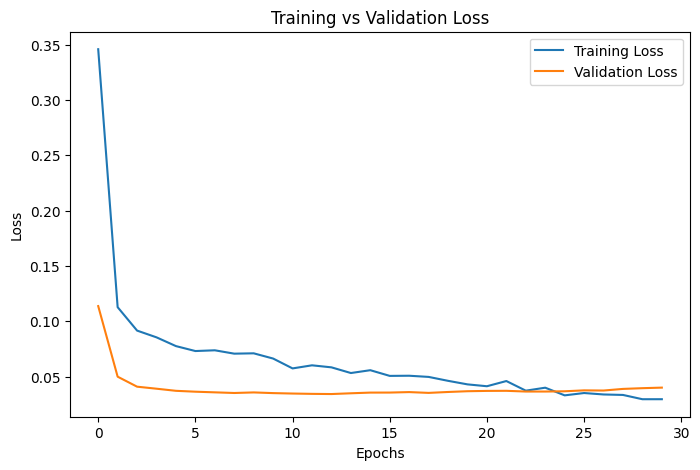

In [38]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.legend()

plt.savefig("loss_curve.png")

plt.show()

## Evaluation Interpretation

The neural network model achieved a test accuracy of approximately 98.5% with a low test loss of around 0.078, indicating strong predictive performance on unseen data.

The training and validation accuracy curves remained consistently high throughout the training process, showing stable learning behavior and effective convergence of the model. Similarly, both training and validation loss decreased steadily across epochs, which suggests that the optimizer successfully minimized prediction error during backpropagation.

The confusion matrix shows that the model correctly classified the majority of non-churn customers. However, the model failed to correctly identify churn cases in the minority class. This is also reflected in the classification report, where class `1` (churn) achieved very low precision and recall values.

This behavior indicates that the dataset is highly imbalanced, causing the neural network to become biased toward predicting the majority class. Although the overall accuracy is very high, the model’s ability to detect churn customers is limited. Therefore, accuracy alone is not sufficient for evaluating imbalanced classification problems.

To improve minority class prediction performance, techniques such as class balancing, SMOTE oversampling, class weights, or threshold tuning could be applied in future experiments.

Overall, the model demonstrated strong generalization capability with minimal overfitting, as training and validation curves remained closely aligned throughout training.

# 8. Hyperparameter Experiments

In [31]:
model_exp1 = Sequential()

model_exp1.add(Dense(64, activation='tanh', input_shape=(X_train.shape[1],)))

model_exp1.add(Dense(32, activation='tanh'))

model_exp1.add(Dense(1, activation='sigmoid'))

model_exp1.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_exp1 = model_exp1.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

loss1, acc1 = model_exp1.evaluate(X_test, y_test)

print("Experiment 1 Test Accuracy:", acc1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9875 - loss: 0.0584  
Experiment 1 Test Accuracy: 0.987500011920929


In [32]:
model_exp2 = Sequential()

model_exp2.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

model_exp2.add(Dense(32, activation='relu'))

model_exp2.add(Dense(1, activation='sigmoid'))

model_exp2.compile(
    optimizer=Adam(learning_rate=0.1),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_exp2 = model_exp2.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

loss2, acc2 = model_exp2.evaluate(X_test, y_test)

print("Experiment 2 Test Accuracy:", acc2)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9850 - loss: 0.0671  
Experiment 2 Test Accuracy: 0.9850000143051147


In [33]:
model_exp3 = Sequential()

model_exp3.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

model_exp3.add(Dense(32, activation='relu'))

model_exp3.add(Dense(1, activation='sigmoid'))

model_exp3.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_exp3 = model_exp3.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

loss3, acc3 = model_exp3.evaluate(X_test, y_test)

print("Experiment 3 Test Accuracy:", acc3)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9875 - loss: 0.0625
Experiment 3 Test Accuracy: 0.987500011920929


In [34]:
comparison_table = pd.DataFrame({
    "Experiment": [
        "Baseline Model",
        "Tanh Activation",
        "High Learning Rate",
        "Without Dropout"
    ],
    "Test Accuracy": [
        accuracy,
        acc1,
        acc2,
        acc3
    ]
})

comparison_table

,Experiment,Test Accuracy
0,Baseline Model,0.9850
1,Tanh Activation,0.9875
2,High Learning Rate,0.9850
3,Without Dropout,0.9875


In [39]:
comparison_table.to_csv("model_comparison_table.csv", index=False)

# 9. Final Reflection

## Role of Weights and Biases

Weights are the learnable parameters of a neural network that determine how strongly each input feature influences the final prediction. During training, the network continuously updates these weights using backpropagation to minimize prediction error. Biases provide additional flexibility by allowing neurons to shift activation values, which improves the model’s ability to fit complex patterns in the data.

## Importance of Activation Functions

Activation functions introduce non-linearity into the neural network. Without activation functions, the model would behave like a simple linear equation and would not be capable of learning complex customer behavior patterns. In this project, the ReLU activation function helped the model train efficiently and achieve stable convergence, while the sigmoid activation function was used in the output layer for binary classification.

## Effect of Learning Rate

The learning rate controls how quickly the neural network updates its parameters during optimization. If the learning rate is too high, training may become unstable and overshoot the optimal solution. If it is too low, the training process becomes very slow and may get stuck before reaching the best performance.

In the hyperparameter experiments, increasing the learning rate still produced strong accuracy because the dataset was relatively simple and highly separable. However, excessively high learning rates can often lead to unstable loss behavior in more complex datasets.

## Underfitting and Overfitting Analysis

The model showed strong generalization performance because both training and validation accuracy remained consistently high throughout training. The validation loss also stayed low and closely followed the training loss curve, indicating that the model learned meaningful patterns without severe overfitting.

The inclusion of dropout regularization further helped reduce overfitting risk by preventing the neural network from relying too heavily on specific neurons during training.

However, evaluation metrics revealed that the dataset was highly imbalanced. Although the model achieved very high overall accuracy, it struggled to correctly classify minority churn cases. This demonstrates that high accuracy alone is not always sufficient for evaluating classification models, especially in imbalanced datasets.

## Insights from Hyperparameter Experiments

The hyperparameter experiments showed that different configurations produced similar accuracy values, indicating that the dataset was relatively easy for the neural network to learn. The Tanh activation function and the removal of dropout produced slightly higher accuracy than the baseline model, while the higher learning rate configuration maintained comparable performance.

These experiments demonstrated how architectural and optimization choices can influence neural network learning behavior and model generalization.

# 10. Conclusion

This project successfully demonstrated how feed-forward neural networks can be applied to a supervised customer churn prediction problem. The model achieved strong predictive performance while also illustrating key neural network concepts such as forward propagation, backpropagation, activation functions, optimization, and hyperparameter tuning.